# LIMOncello — bản thứ hai: **SGal(3) + IESKF** giải chậm và chi tiết

## Notebook này dành cho ai?

Notebook này dành cho người đã đọc bản đầu tiên, hoặc đã có hình dung sơ bộ về bài báo, nhưng vẫn còn thấy:

- `SGal(3)` nghe rất lạ,
- `IESKF` trên manifold vẫn còn mơ hồ,
- ký hiệu `⊕`, `⊖`, `⊞`, `Ad`, `J_r`, `J_j` nhìn rất “ngợp”,
- và đặc biệt là chưa thật sự thấy **vì sao tác giả lại chọn SGal(3)** thay vì chỉ dùng \(SO(3)\times \mathbb{R}^6\).

Bản thứ hai này cố ý đi **chậm hơn** và **toán hơn** bản trước.

---

## Mục tiêu của bản thứ hai

Ở cuối notebook này, bạn nên nắm được 6 ý lớn:

1. **Kalman Filter → EKF → ESKF → IESKF** khác nhau ở đâu.
2. Trạng thái “sống trên manifold” nghĩa là gì, và vì sao sai số lại được đặt trong **tangent space**.
3. **\(S^2\)** được dùng cho gravity như thế nào, và vì sao nó chỉ có **2 bậc tự do**.
4. **\(SGal(3)\)** thực ra đang mô tả điều gì: rotation, velocity, position, và time gắn với nhau ra sao.
5. Vì sao phép cập nhật của paper
   \[
   \Gamma \leftarrow \Gamma \oplus 
   \begin{bmatrix}
   0\\ a\\ \omega\\ 1
   \end{bmatrix}\Delta t
   \]
   lại “đẻ ra” được cả **vận tốc** lẫn **vị trí**, dù thành phần vị trí trong tangent increment là 0.
6. Measurement update của LIMOncello thực chất là một bài toán **MAP + relinearization**, và đó là lý do nó mang tinh thần **iterated**.

---

## Nguồn mà notebook này bám theo

Notebook này chủ yếu bám theo các nguồn sau:

- **[P0]** Carlos Perez-Ruiz, Joan Solà,  
  *LIMOncello: Iterated Error-State Kalman Filter on the SGal(3) Manifold for Fast LiDAR–Inertial Odometry*.
- **[P1]** D. He, W. Xu, F. Zhang,  
  *Symbolic Representation and Toolkit Development of Iterated Error-State Extended Kalman Filters on Manifolds*.
- **[P2]** Joan Solà et al.,  
  *A Micro Lie Theory for State Estimation in Robotics*.
- **[P3]** Jonathan Kelly,  
  *All About the Galilean Group SGal(3)*.
- **[P4]** Joan Solà,  
  *Quaternion Kinematics for the Error-State Kalman Filter*.
- **[P5]** FAST-LIO / FAST-LIO2 / i-Octree để đặt LIMOncello vào đúng bối cảnh.

Ở phần cuối notebook có **mục reference đầy đủ** và **gợi ý thứ tự đọc**.

---

## Cách dùng notebook này

Bạn không cần đọc một lèo từ đầu đến cuối. Có thể đi theo lộ trình:

- nếu bạn chưa vững filter: đọc phần **Kalman → EKF → ESKF → IESKF**
- nếu bạn ngại manifold: đọc phần **đường tròn, tangent space, \(S^2\), \(SO(3)\)**
- nếu bạn muốn hiểu cái mới của paper: đọc phần **SGal(3)** và **Eq. (10)–(12)**
- nếu bạn muốn hiểu backend tối ưu: đọc phần **point-to-plane residual** và **Eq. (19)–(20)**

Trong notebook này, mình sẽ thường xuyên ghi rõ:

- **“Trực giác”**: hiểu theo kiểu đơn giản.
- **“Mặt toán”**: viết lại đúng theo paper hơn.
- **“Điều bạn cần nhớ”**: thứ quan trọng nhất sau mỗi đoạn.

# 1. Trước khi vào manifold: ta đang ước lượng cái gì?

Trong LiDAR–Inertial Odometry, robot đang cố ước lượng ít nhất các đại lượng sau:

- **orientation**: robot đang quay theo hướng nào,
- **position**: robot đang ở đâu,
- **velocity**: robot đang đi nhanh theo hướng nào,
- **bias IMU**: cảm biến có đang lệch hay không,
- **gravity direction**: hướng của trọng lực trong hệ toạ độ liên quan.

Nghe thì có vẻ như chỉ cần gom tất cả vào một vector to rồi chạy filter.

Ví dụ ta có thể tưởng tượng kiểu:

\[
x = [p,\; v,\; \theta,\; b_\omega,\; b_a,\; g].
\]

Nhưng vấn đề nằm ở chỗ:

- **position** và **velocity** là vector Euclid bình thường,
- còn **rotation** thì không phải vector Euclid bình thường,
- còn **gravity direction** có độ lớn gần như cố định nên nó cũng không nên được phép “trôi tự do” trong \(\mathbb{R}^3\).

Nói gọn:

> Không phải thành phần nào của state cũng “cộng trừ như vector thường” được.

Đó là nguyên nhân sâu xa khiến bài báo phải bước sang thế giới:

- **manifold**,
- **Lie group**,
- **error-state**,
- và cuối cùng là **IESKF on manifolds**.

---

## Một cách nhìn rất thực tế

Trong robotics, có hai lớp biến:

### Lớp 1: biến “phẳng”
Ví dụ:

- bias gyroscope,
- bias accelerometer,
- vài tham số hiệu chuẩn,
- noise nhỏ.

Các biến này sống tốt trong \(\mathbb{R}^n\). Cộng trừ bình thường là ổn.

### Lớp 2: biến “có ràng buộc hình học”
Ví dụ:

- rotation phải luôn là rotation hợp lệ,
- gravity direction phải giữ độ lớn cố định,
- pose nên cập nhật theo phép hợp thành hình học, không phải cộng bừa.

Đây là nơi manifold xuất hiện.

---

## Điều cần nhớ

Khi paper nói “filter on manifolds”, ý cốt lõi không phải là làm toán cho sang.

Ý cốt lõi là:

> **biểu diễn state đúng theo hình học của chính nó**,  
> để khi update/predict, state vẫn luôn hợp lệ.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm, norm
from scipy.optimize import minimize_scalar

np.set_printoptions(precision=5, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11

def skew(w):
    w = np.asarray(w, dtype=float).reshape(3)
    return np.array([
        [0.0, -w[2],  w[1]],
        [w[2],  0.0, -w[0]],
        [-w[1], w[0], 0.0],
    ])

def so3_exp(phi):
    phi = np.asarray(phi, dtype=float).reshape(3)
    angle = np.linalg.norm(phi)
    K = skew(phi)
    if angle < 1e-10:
        return np.eye(3) + K + 0.5 * (K @ K)
    A = np.sin(angle) / angle
    B = (1 - np.cos(angle)) / (angle ** 2)
    return np.eye(3) + A * K + B * (K @ K)

def sgal_matrix(R=None, v=None, p=None, t=0.0):
    R = np.eye(3) if R is None else np.asarray(R, dtype=float).reshape(3, 3)
    v = np.zeros(3) if v is None else np.asarray(v, dtype=float).reshape(3)
    p = np.zeros(3) if p is None else np.asarray(p, dtype=float).reshape(3)
    G = np.eye(5)
    G[:3, :3] = R
    G[:3, 3] = v
    G[:3, 4] = p
    G[3, 4] = float(t)
    return G

def sgal_wedge(rho=None, nu=None, theta=None, iota=0.0):
    rho = np.zeros(3) if rho is None else np.asarray(rho, dtype=float).reshape(3)
    nu = np.zeros(3) if nu is None else np.asarray(nu, dtype=float).reshape(3)
    theta = np.zeros(3) if theta is None else np.asarray(theta, dtype=float).reshape(3)
    Xi = np.zeros((5, 5))
    Xi[:3, :3] = skew(theta)
    Xi[:3, 3] = nu
    Xi[:3, 4] = rho
    Xi[3, 4] = float(iota)
    return Xi

def sgal_inverse_formula(R, v, p, t):
    R = np.asarray(R, dtype=float).reshape(3, 3)
    v = np.asarray(v, dtype=float).reshape(3)
    p = np.asarray(p, dtype=float).reshape(3)
    Rt = R.T
    v_inv = -Rt @ v
    p_inv = Rt @ (v * t - p)
    t_inv = -t
    return Rt, v_inv, p_inv, t_inv

def transform_event(G, x, tau):
    x = np.asarray(x, dtype=float).reshape(3)
    event = np.r_[x, float(tau), 1.0]
    out = G @ event
    return out[:3], out[3]

def tangent_basis_s2(x):
    x = np.asarray(x, dtype=float).reshape(3)
    x = x / np.linalg.norm(x)
    # chọn một vector không song song với x
    if abs(x[2]) < 0.9:
        a = np.array([0.0, 0.0, 1.0])
    else:
        a = np.array([1.0, 0.0, 0.0])
    b1 = a - x * (x @ a)
    b1 = b1 / np.linalg.norm(b1)
    b2 = np.cross(x, b1)
    b2 = b2 / np.linalg.norm(b2)
    return np.column_stack([b1, b2])

def s2_plus(x, tau):
    x = np.asarray(x, dtype=float).reshape(3)
    tau = np.asarray(tau, dtype=float).reshape(2)
    B = tangent_basis_s2(x)
    return so3_exp(B @ tau) @ x

def plane_residual(n, q, y):
    n = np.asarray(n, dtype=float).reshape(3)
    q = np.asarray(q, dtype=float).reshape(3)
    y = np.asarray(y, dtype=float).reshape(3)
    return float(n @ (y - q))

def residual_pose(R, t, point, n, q):
    y = R @ point + t
    return plane_residual(n, q, y)


# 2. Kalman Filter → EKF → ESKF → IESKF: khác nhau ở đâu?

Đây là phần rất quan trọng. Nếu chỗ này mơ hồ thì đọc công thức của paper sẽ rất nặng.

---

## 2.1 Kalman Filter thường

Kalman Filter “kinh điển” giả định:

- mô hình động học **tuyến tính**,
- mô hình đo **tuyến tính**,
- noise Gaussian.

Dạng quen thuộc:

\[
x_{k+1} = F x_k + w_k,\qquad z_k = H x_k + v_k.
\]

Khi đó ta có:

- **predict**: dùng mô hình để đẩy state đi tiếp,
- **update**: dùng measurement để kéo state về gần thực tế hơn.

Tất cả đều gọn vì hệ là tuyến tính.

---

## 2.2 Nhưng robot thật hiếm khi tuyến tính

Trong LIO:

- rotation là phi tuyến,
- biến đổi điểm 3D qua pose là phi tuyến,
- residual point-to-plane phụ thuộc pose phi tuyến,
- state còn sống trên manifold.

Do đó không thể nhét thẳng vào Kalman Filter tuyến tính.

---

## 2.3 EKF

**Extended Kalman Filter (EKF)** giải quyết chuyện này bằng cách:

1. giữ nguyên mô hình phi tuyến,
2. nhưng tại mỗi bước chỉ **xấp xỉ tuyến tính** quanh estimate hiện tại.

Tức là:

- mô hình thật là phi tuyến,
- nhưng mỗi lần ta “zoom local” vào một vùng nhỏ,
- rồi dùng Jacobian để chạy công thức Kalman như thể nó gần tuyến tính ở đó.

Đây là một ý rất mạnh:

> Ta không cần cả thế giới phải tuyến tính.  
> Ta chỉ cần **cục bộ quanh điểm hiện tại** đủ gần tuyến tính.

---

## 2.4 ESKF

**Error-State Kalman Filter (ESKF)** đi thêm một bước nữa.

Thay vì filter trực tiếp trên toàn bộ state “lớn” một cách ngây thơ, nó tách ra:

- **nominal state**: state chính, được propagate phi tuyến một cách tử tế,
- **error state**: sai số nhỏ quanh nominal state, được coi là đủ nhỏ để tuyến tính hóa tốt.

Ý tưởng:

\[
x^\star = x \oplus \delta x.
\]

Ở đây:

- \(x^\star\): true state,
- \(x\): nominal state,
- \(\delta x\): error nhỏ trong tangent space.

Với rotation, điều này cực hợp lý:

- state chính vẫn là rotation hợp lệ,
- còn filter chỉ xử lý **nhiễu quay nhỏ** dưới dạng vector nhỏ.

---

## 2.5 IESKF

Chữ **I** trong IESKF là **Iterated**.

Nó có nghĩa là:

- trong bước update với measurement,
- ta không tuyến tính hóa đúng **một lần** rồi chốt,
- mà có thể **relinearize nhiều lần** quanh estimate mới nhất,
- cho đến khi hội tụ hoặc đạt số lần lặp tối đa.

Trực giác rất giống Gauss–Newton:

1. tuyến tính hóa quanh estimate hiện tại,
2. giải một bước update,
3. nhảy sang estimate mới,
4. lại tuyến tính hóa quanh điểm mới,
5. lặp tiếp.

Khi measurement rất phi tuyến, điều này thường ổn hơn EKF chỉ linearize một lần.

---

## Điều cần nhớ

- **KF**: tuyến tính thật sự.
- **EKF**: phi tuyến nhưng linearize một lần quanh estimate hiện tại.
- **ESKF**: filter trên **sai số nhỏ**, không phải trực tiếp trên toàn bộ state.
- **IESKF**: ESKF + **lặp** trong bước measurement update.

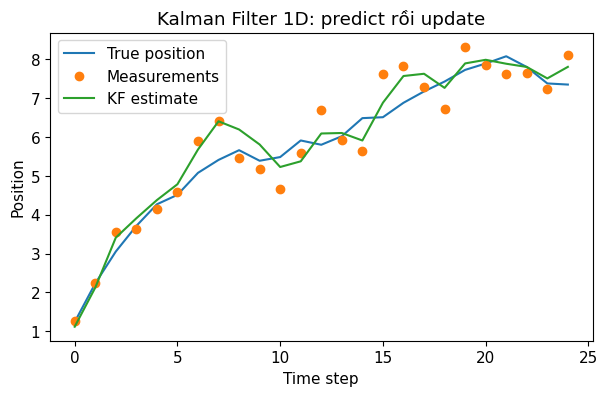

In [2]:

# Ví dụ 1: Kalman Filter 1D rất cơ bản
# Mục tiêu: chỉ để thấy predict / update hoạt động ra sao trong trường hợp tuyến tính.

np.random.seed(7)

dt = 1.0
F = np.array([[1.0, dt],
              [0.0, 1.0]])         # state = [position, velocity]
H = np.array([[1.0, 0.0]])         # chỉ đo position
Q = np.diag([0.02, 0.02])
R = np.array([[0.25]])

x_true = np.array([0.0, 1.0])
x_est = np.array([0.0, 0.0])
P = np.diag([1.0, 1.0])

true_positions = []
measurements = []
est_positions = []

for k in range(25):
    # true dynamics
    process_noise = np.random.multivariate_normal(np.zeros(2), Q)
    x_true = F @ x_true + process_noise

    # measurement
    meas_noise = np.random.normal(0.0, np.sqrt(R[0, 0]))
    z = H @ x_true + meas_noise

    # predict
    x_pred = F @ x_est
    P_pred = F @ P @ F.T + Q

    # update
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_est = x_pred + (K @ (z - H @ x_pred)).ravel()
    P = (np.eye(2) - K @ H) @ P_pred

    true_positions.append(x_true[0])
    measurements.append(float(z.item()))
    est_positions.append(x_est[0])

plt.figure()
plt.plot(true_positions, label="True position")
plt.plot(measurements, marker="o", linestyle="", label="Measurements")
plt.plot(est_positions, label="KF estimate")
plt.xlabel("Time step")
plt.ylabel("Position")
plt.title("Kalman Filter 1D: predict rồi update")
plt.legend()
plt.show()


### Đọc ví dụ trên như thế nào?

- Dấu chấm rời rạc là **measurement**: khá nhiễu.
- Đường “true position” là quỹ đạo thật.
- Đường “KF estimate” là estimate sau khi mỗi lần:
  - dự đoán bằng động học,
  - rồi chỉnh lại bằng measurement.

Nếu hệ tuyến tính, đây chính là thế mạnh của KF: rất sạch, rất gọn.

Nhưng LiDAR–IMU odometry không đẹp như vậy:

- rotation không tuyến tính,
- transform điểm qua pose là phi tuyến,
- state có manifold.

Vì vậy ta cần EKF/ESKF/IESKF.

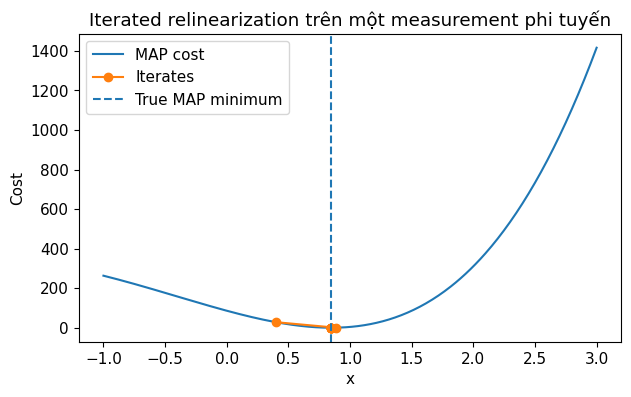

,iteration,x_iter,cost(x_iter)
0,0,0.400000,29.070312
1,1,0.884412,1.373752
2,2,0.848312,1.153635
3,3,0.847901,1.153607
4,4,0.847899,1.153607
5,5,0.847899,1.153607
6,6,0.847899,1.153607
7,7,0.847899,1.153607
8,8,0.847899,1.153607


In [3]:

# Ví dụ 2: một update phi tuyến kiểu "iterated"
# Đây KHÔNG phải toàn bộ IESKF của paper.
# Nó chỉ là ví dụ 1D để thấy tại sao "lặp relinearization" có ích.

# Bài toán:
#   prior: x ~ N(mu, P)
#   measurement: z = h(x) + noise, với h(x) = x + 0.25 x^2
# Ta sẽ tìm MAP bằng cách linearize lặp quanh x_j.

mu = 0.4
P = 0.30**2
z = 1.05
R = 0.08**2

def h(x):
    return x + 0.25 * x**2

def H_jac(x):
    return 1.0 + 0.5 * x

def cost(x):
    return 0.5 * (z - h(x))**2 / R + 0.5 * (x - mu)**2 / P

x = mu
history = [x]
for _ in range(8):
    H = H_jac(x)
    r = z - h(x)               # residual tại điểm hiện tại
    # giải bài toán quadratic sau khi linearize h quanh x
    dx = (H * r / R - (x - mu) / P) / (H * H / R + 1.0 / P)
    x = x + dx
    history.append(float(x))

x_map = minimize_scalar(cost, bounds=(-1, 3), method="bounded").x

xs = np.linspace(-1, 3, 400)
plt.figure()
plt.plot(xs, [cost(v) for v in xs], label="MAP cost")
plt.plot(history, [cost(v) for v in history], marker="o", label="Iterates")
plt.axvline(x_map, linestyle="--", label="True MAP minimum")
plt.xlabel("x")
plt.ylabel("Cost")
plt.title("Iterated relinearization trên một measurement phi tuyến")
plt.legend()
plt.show()

pd.DataFrame({
    "iteration": np.arange(len(history)),
    "x_iter": history,
    "cost(x_iter)": [cost(v) for v in history]
})


### Ví dụ phi tuyến ở trên đang dạy điều gì?

Trong ví dụ này:

- measurement model là phi tuyến: \(h(x)=x+0.25x^2\),
- ta có prior Gaussian,
- ta muốn tìm estimate tốt nhất sau khi kết hợp prior và measurement.

Nếu linearize đúng một lần ở một chỗ tệ, update có thể không tối ưu.

Khi ta **lặp**:

- Jacobian được tính lại quanh estimate mới,
- residual cũng được tính lại quanh estimate mới,
- nghiệm dần tiến về điểm cực tiểu tốt hơn.

Đó chính là trực giác quan trọng của **Iterated ESKF / IESKF**.

---

## Liên hệ với LIMOncello

Trong LIMOncello:

- measurement không phải là 1D đơn giản,
- mà là cả một bó residual point-to-plane từ point cloud,
- state sống trên manifold,
- covariance còn phải được “chuyển” giữa các tangent space khi điểm linearize thay đổi.

Nhưng tinh thần vẫn là:

> linearize → update → relinearize → update → ... cho đến khi hội tụ.

# 3. Manifold và tangent space — giải thật chậm

Đây là phần cốt lõi nhất nếu bạn muốn hiểu vì sao paper viết

\[
x^\star = x \oplus \delta x
\]

thay vì chỉ viết

\[
x^\star = x + \delta x.
\]

---

## 3.1 Một ví dụ 2D rất hiền: điểm trên đường tròn

Giả sử state của bạn là một điểm nằm trên đường tròn đơn vị.

Nếu bạn “cộng toạ độ bừa” trong \(\mathbb{R}^2\), điểm mới có thể **rơi khỏi đường tròn**.

Nhưng nếu bạn update bằng một increment nhỏ trong **không gian tiếp tuyến** tại điểm hiện tại, rồi “quấn” nó trở lại đường tròn, state mới vẫn hợp lệ.

Đây chính là tinh thần của:

- **tangent increment**,
- **retraction / Exp map**,
- **update on manifold**.

---

## 3.2 Tangent space là gì?

Tangent space là một không gian tuyến tính “áp sát” manifold tại một điểm.

Ta dùng tangent space để chứa:

- sai số nhỏ,
- increment nhỏ,
- covariance,
- Jacobian.

Nói cách khác:

- **state thật** ở trên manifold,
- **nhiễu nhỏ quanh state** ở trong tangent space.

Đây là lý do các paper estimation trên manifold hay nói:

> “uncertainty is represented in the tangent space.”

---

## 3.3 Một câu rất quan trọng

**Covariance không sống trôi nổi ở đâu cũng được.**  
Nó luôn gắn với một **tọa độ cục bộ** nào đó.

Khi estimate di chuyển trên manifold, tangent space gắn với estimate cũng thay đổi.

Đó là lý do ở phần update iterated, paper phải có thêm \(J_j\):

- để **chuyển covariance đã propagate** sang tangent space tại iterate hiện tại.

Đây là một chi tiết nhiều người mới học hay bỏ qua.

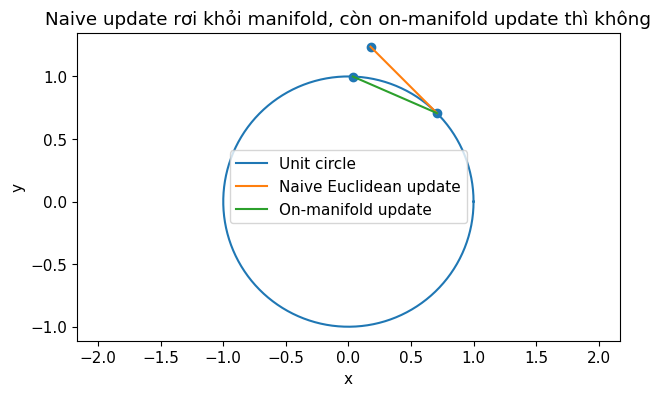

Norm của x            = 1.0
Norm của y_naive      = 1.25
Norm của y_manifold   = 1.0


In [4]:

# Minh hoạ: cập nhật trên đường tròn
theta0 = np.pi / 4
tau = 0.75  # increment trong tangent space (1 chiều vì đường tròn là manifold 1D)

x = np.array([np.cos(theta0), np.sin(theta0)])
tangent_dir = np.array([-np.sin(theta0), np.cos(theta0)])  # vector tiếp tuyến tại x

# "naive" update trong Euclid
y_naive = x + tau * tangent_dir

# update đúng kiểu manifold: quay quanh tâm một góc tau
theta1 = theta0 + tau
y_manifold = np.array([np.cos(theta1), np.sin(theta1)])

t = np.linspace(0, 2*np.pi, 400)
circle = np.column_stack([np.cos(t), np.sin(t)])

plt.figure()
plt.plot(circle[:, 0], circle[:, 1], label="Unit circle")
plt.plot([x[0], y_naive[0]], [x[1], y_naive[1]], label="Naive Euclidean update")
plt.plot([x[0], y_manifold[0]], [x[1], y_manifold[1]], label="On-manifold update")
plt.scatter([x[0], y_naive[0], y_manifold[0]], [x[1], y_naive[1], y_manifold[1]])
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Naive update rơi khỏi manifold, còn on-manifold update thì không")
plt.legend()
plt.show()

print("Norm của x            =", np.linalg.norm(x))
print("Norm của y_naive      =", np.linalg.norm(y_naive))
print("Norm của y_manifold   =", np.linalg.norm(y_manifold))


### Bài học từ hình trên

- Điểm **naive** bị bật ra khỏi đường tròn.
- Điểm **on-manifold** vẫn nằm đúng trên đường tròn.

Trong 3D rotation, chuyện này còn nghiêm trọng hơn:

- nếu update sai, ma trận có thể không còn trực chuẩn,
- quaternion có thể mất chuẩn,
- Jacobian / covariance có thể trở nên vô nghĩa hình học.

---

## 3.4 `⊕` và `⊖` nên hiểu thế nào?

Trong rất nhiều paper về Lie group / manifold:

### `Y = X ⊕ τ`
nghĩa là:

- bạn đang ở state \(X\) trên manifold,
- bạn có một increment nhỏ \(\tau\) trong tangent space,
- bạn dùng phép cập nhật hình học để đi tới \(Y\).

### `τ = Y ⊖ X`
nghĩa là:

- bạn đã có hai điểm \(X, Y\) trên manifold,
- bạn muốn biểu diễn “độ lệch từ \(X\) sang \(Y\)” bằng một vector cục bộ trong tangent space.

Nói dân dã:

- `⊕` = **đi từ manifold + increment**
- `⊖` = **lấy hai state trên manifold rồi đổi thành local error**

---

## 3.5 Và còn `⊞`?

Trong paper này, `⊞` được dùng cho **propagation / time evolution** trên một manifold nói chung.

Điểm tinh tế là:

- với Lie group, propagation thường có thể viết tự nhiên bằng `⊕`,
- nhưng khi state có phần không hẳn là Lie group, hoặc cách ghép state đòi hỏi cẩn thận hơn, ta dùng một toán tử update tổng quát hơn.

Vì vậy paper viết:

\[
x_{k+1} = x_k \;\boxplus\; f(x_k,u_k,w_k).
\]

Bạn có thể hiểu thô như sau:

> `⊞` là phép “đẩy state đi một bước thời gian”  
> bằng increment do động học sinh ra.

Nó tổng quát hơn `⊕`, nhưng cùng tinh thần:  
**increment sống ở local coordinates, state sống trên manifold**.

# 4. Từ Lie group đến error-state trong paper

Trong phần preliminaries, paper đi qua 3 bước logic rất quan trọng:

1. nhắc lại manifold / Lie group / tangent space,
2. định nghĩa `⊕`, `⊖`,
3. rồi nói sang **true-state = nominal-state ⊕ error-state**.

Ta viết lại cực chậm.

---

## 4.1 State thật và state danh nghĩa

Paper viết:

\[
x^\star = x \oplus \delta x.
\]

Ý nghĩa:

- \(x^\star\): state thật nhưng ta không biết trực tiếp,
- \(x\): nominal state mà filter đang giữ,
- \(\delta x\): sai số nhỏ quanh nominal state.

Tại sao cách này mạnh?

Vì nominal state có thể được propagate bằng hình học đúng của nó:

- rotation vẫn là rotation,
- gravity direction vẫn có norm cố định,
- pose vẫn nằm trong group hợp lệ.

Còn filter chỉ cần quản lý \(\delta x\), thứ nhỏ và gần tuyến tính hơn.

---

## 4.2 Time update của true state

Paper viết:

\[
x^\star \leftarrow x^\star \boxplus f(x^\star, u, w).
\]

Ở đây:

- \(u\): input / control, trong LIO chính là IMU measurements,
- \(w\): noise,
- \(f(\cdot)\): hàm sinh ra increment trong một khoảng \(\Delta t\).

Bản chất:

- true state được đẩy đi bởi động học thật,
- nominal state được đẩy đi bởi cùng động học nhưng bỏ noise,
- hiệu giữa hai quá trình đó sinh ra **error dynamics**.

---

## 4.3 Công thức then chốt của error propagation

Paper thay \(x^\star = x \oplus \delta x\) vào time update và thu được biểu thức của \(\delta x_{k+1}\).

Rồi linearize:

\[
\delta x_{k+1} \simeq F_{\delta x}\,\delta x_k + F_w\,w.
\]

Đây chính là nơi IESKF/EKF xuất hiện:

- mọi phi tuyến phức tạp của manifold và động học
- cuối cùng được gom lại thành hai Jacobian local:
  - \(F_{\delta x}\): error-state transition,
  - \(F_w\): noise injection.

Sau đó covariance được propagate như EKF quen thuộc:

\[
P \leftarrow F_{\delta x} P F_{\delta x}^\top + F_w Q F_w^\top.
\]

---

## 4.4 `Adjoint` và `Right Jacobian` trong Eq. (9) đang làm gì?

Khi state sống trên Lie group, paper viết lại \(F_{\delta x}\) và \(F_w\) bằng:

- **Adjoint** \(Ad\),
- **right Jacobian** \(J_r\).

Bạn chưa cần thuộc công thức đóng. Chỉ cần hiểu:

### Adjoint
Adjoint là công cụ đổi cách biểu diễn một perturbation nhỏ khi “đi theo” group element.

Trực giác:

- cùng một sai số hình học nhỏ,
- nhưng nếu bạn đổi gốc biểu diễn / đổi base point trên group,
- tọa độ local của sai số đó sẽ đổi theo.

Adjoint mô tả đúng phép đổi đó.

### Right Jacobian
Right Jacobian là hệ số hiệu chỉnh khi bạn biến một increment nhỏ trong tangent space thành chuyển động thật trên Lie group bằng hàm Exp.

Nó xuất hiện vì:

- manifold cong,
- nên quan hệ giữa “increment nhỏ” và “dịch chuyển thật” không phải lúc nào cũng là đồng nhất tuyến tính.

---

## Điều cần nhớ

Nếu đọc Eq. (6)–(9) mà thấy nặng, hãy chỉ giữ 1 câu này:

> Paper đang làm đúng điều EKF luôn làm:  
> tìm **Jacobian của error-state dynamics**.

Điều khác biệt là:

- error-state nằm trong tangent space của manifold,
- nên Jacobian phải “aware” tới hình học Lie group.

In [5]:

# Một mẩu tính toán nhỏ với SO(3): Exp(phi) tạo ra ma trận quay hợp lệ

phi = np.array([0.20, -0.10, 0.05])   # increment quay nhỏ trong tangent space
R = so3_exp(phi)

print("R =")
print(R)
print("\nR^T R =")
print(R.T @ R)
print("\ndet(R) =", np.linalg.det(R))


R =
[[ 0.99378 -0.05952 -0.09415]
 [ 0.03961  0.97884 -0.20074]
 [ 0.10411  0.19577  0.97511]]

R^T R =
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

det(R) = 0.9999999999999999


Ở đây \(\phi\in\mathbb{R}^3\) là một vector nhỏ trong tangent space của \(SO(3)\).  
Sau khi đi qua `Exp`, ta nhận được một ma trận quay hợp lệ \(R\):

- \(R^\top R \approx I\),
- \(\det(R)\approx 1\).

Đó là khác biệt giữa:

- **update hình học đúng**,
- và **cộng trừ ma trận/quaternion một cách ngây thơ**.

# 5. \(S^2\): vì sao gravity lại được đặt trên mặt cầu?

Paper chọn gravity vector trên manifold:

\[
S^2(r) = \{x \in \mathbb{R}^3 : \|x\| = r\}.
\]

Nếu \(r\) là độ lớn của gravity, thì state gravity không còn là “bất kỳ vector nào trong \(\mathbb{R}^3\)” nữa, mà là:

- **độ lớn cố định**,
- chỉ còn **hướng** là cần ước lượng.

Đây là một lựa chọn rất hợp lý về mặt vật lý.

---

## 5.1 Vì sao không để gravity trong \(\mathbb{R}^3\) luôn?

Nếu để gravity là vector tự do trong \(\mathbb{R}^3\), filter có thể vô tình:

- làm độ lớn của gravity thay đổi linh tinh,
- trong khi vật lý thật nói rằng độ lớn này gần như cố định.

Dùng \(S^2\) nghĩa là ta ép state phải tôn trọng ràng buộc hình học đó.

---

## 5.2 Vì sao \(S^2\) chỉ có 2 bậc tự do?

Một vector 3 chiều có 3 thành phần, nhưng nếu bị ép:

\[
x_1^2 + x_2^2 + x_3^2 = r^2,
\]

thì 1 ràng buộc làm mất đi 1 bậc tự do.

Nên:

- biểu diễn ngoài là 3D,
- nhưng manifold thực chất là **2D**.

Đó là lý do increment local \(\tau\) cho \(S^2\) sống trong \(\mathbb{R}^2\), không phải \(\mathbb{R}^3\).

---

## 5.3 Ý nghĩa của \(B(x)\)

Paper định nghĩa một cơ sở tiếp tuyến cục bộ:

\[
B(x) \in \mathbb{R}^{3\times 2}.
\]

Hai cột của \(B(x)\):

- nằm trên mặt phẳng tiếp tuyến tại \(x\),
- trực chuẩn với nhau,
- và đều vuông góc với \(x\).

Khi đó một increment local \(\tau\in\mathbb{R}^2\) sẽ được “nhúng” thành vector 3D trong tangent plane bằng \(B(x)\tau\).

Sau đó paper dùng một rotation nhỏ để đẩy \(x\) đi trên mặt cầu:

\[
x \oplus \tau = SO(3)\mathrm{Exp}(B(x)\tau)\,x.
\]

Ý này rất đẹp:

- \(\tau\) chỉ là toạ độ local 2D,
- \(B(x)\tau\) biến nó thành một “trục-góc quay nhỏ” trong 3D,
- rồi quay \(x\) theo lượng đó.

---

## 5.4 `⊖` trên \(S^2\)

Công thức `⊖` của paper làm điều ngược lại:

- từ hai điểm \(x, y\) trên mặt cầu,
- tìm ra local tangent coordinates \(\tau\in\mathbb{R}^2\)
- sao cho \(y\) có thể xem như \(x \oplus \tau\).

Khi góc rất nhỏ, paper còn đưa ra xấp xỉ bậc một:

\[
y \ominus x \simeq B(x)^\top (x \times y).
\]

Đây là lý do khi hai hướng rất gần nhau, local error của gravity có thể xử lý gần tuyến tính.

In [6]:

# Minh hoạ một increment trên S^2

g = np.array([0.3, -0.4, 1.0])
g = 9.81 * g / np.linalg.norm(g)

B = tangent_basis_s2(g)
tau = np.array([0.08, -0.05])

g_new = s2_plus(g, tau)

print("||g||      =", np.linalg.norm(g))
print("||g_new||  =", np.linalg.norm(g_new))
print("\nB^T g =")
print(B.T @ g)
print("\nB^T B =")
print(B.T @ B)
print("\ng =")
print(g)
print("\ng_new =")
print(g_new)


||g||      = 9.81
||g_new||  = 9.81

B^T g =
[0. 0.]

B^T B =
[[ 1. -0.]
 [-0.  1.]]

g =
[ 2.6323  -3.50973  8.77433]

g_new =
[ 3.51034 -3.3744   8.51628]


### Đọc kết quả trên

- `B^T g ≈ 0`  
  nghĩa là hai cột của \(B\) thực sự nằm trong mặt phẳng tiếp tuyến tại \(g\).

- `B^T B ≈ I`  
  nghĩa là cơ sở tangent local là trực chuẩn.

- `||g_new|| ≈ ||g||`  
  nghĩa là update trên \(S^2\) giữ nguyên độ lớn gravity.

Đó chính là điều paper muốn:  
ước lượng **hướng** gravity mà không phá hỏng **độ lớn** của nó.

# 6. Bây giờ tới phần mới thật sự của paper: **SGal(3)**

Đây là nơi LIMOncello khác đáng kể so với rất nhiều LIO trước đó.

Paper nhấn mạnh rằng nhiều hệ LIO truyền thống dùng một biểu diễn “bundle / compound” kiểu:

\[
SO(3)\times \mathbb{R}^6
\]

tức là:

- rotation ở một chỗ,
- velocity và position ở một chỗ khác.

Cách đó rất tiện, nhưng nó có thể bỏ qua một số **ghép nối hình học / động học** giữa:

- rotation,
- velocity,
- position,
- time.

Paper muốn giữ mối liên hệ đó tốt hơn bằng cách dùng:

\[
SGal(3).
\]

---

## 6.1 SGal(3) chứa những gì?

Một phần tử của \(SGal(3)\) có thể viết dưới dạng ma trận \(5\times5\):

\[
\Gamma =
\begin{bmatrix}
R & v & p\\
0 & 1 & t\\
0 & 0 & 1
\end{bmatrix}
\]

với:

- \(R\in SO(3)\): rotation,
- \(v\in\mathbb{R}^3\): velocity,
- \(p\in\mathbb{R}^3\): position,
- \(t\in\mathbb{R}\): time.

Ở mức độ “đếm số chiều”, group này có:

- 3 chiều cho rotation,
- 3 cho velocity,
- 3 cho position,
- 1 cho time,

tổng cộng **10 chiều**.

---

## 6.2 Cái nhìn đẹp nhất: SGal(3) tác động lên **event**

Một “event” trong không-thời-gian Galilean có thể viết thành homogeneous coordinates:

\[
\begin{bmatrix}
x\\ \tau \\ 1
\end{bmatrix}
\]

với:

- \(x\in\mathbb{R}^3\): vị trí không gian,
- \(\tau\in\mathbb{R}\): thời điểm của event.

Khi nhân với \(\Gamma\), ta được:

\[
\begin{bmatrix}
x'\\ \tau'\\ 1
\end{bmatrix}
=
\Gamma
\begin{bmatrix}
x\\ \tau\\ 1
\end{bmatrix}
=
\begin{bmatrix}
R x + v\tau + p\\
\tau + t\\
1
\end{bmatrix}.
\]

Đây là công thức trực giác nhất của toàn bộ SGal(3).

Nó nói rằng toạ độ không gian mới gồm 3 phần:

1. **quay**: \(Rx\)
2. **boost do thời gian**: \(v\tau\)
3. **tịnh tiến**: \(p\)

---

## 6.3 Tại sao \(v\tau\) quan trọng?

Chính hạng tử \(v\tau\) nói lên bản chất Galilean:

> nếu một frame có vận tốc tương đối \(v\),  
> thì vị trí quan sát được của một event phụ thuộc vào **thời điểm** \(\tau\).

Đây là thứ mà bạn không nhìn thấy rõ ràng khi chỉ dùng pose thuần tuý kiểu \(SE(3)\).

Nó là lý do paper nhấn mạnh:

- uncertainty in time
- kéo theo uncertainty in space.

Trong bối cảnh IMU propagation, điều này rất tự nhiên.

In [7]:

# Minh hoạ trực tiếp công thức event transform trong SGal(3)
# Lấy một ví dụ giống trực giác của Kelly:
# - quay 90 độ quanh trục z
# - boost theo trục x
# - tịnh tiến theo y
# - dịch thời gian

angle = np.pi / 2
R = so3_exp(np.array([0.0, 0.0, angle]))
v = np.array([2.0, 0.0, 0.0])
p = np.array([0.0, 1.0, 0.0])
t_shift = -1.0

G = sgal_matrix(R, v, p, t_shift)

x_local = np.array([1.0, 1.0, 0.0])
tau_local = 2.0

x_global, tau_global = transform_event(G, x_local, tau_local)

print("x_local   =", x_local)
print("tau_local =", tau_local)
print("\nG =")
print(G)
print("\nKết quả:")
print("x_global  =", x_global)
print("tau_global=", tau_global)

# tách từng thành phần để thấy trực giác
rot_part = R @ x_local
boost_part = v * tau_local
trans_part = p

print("\nPhân rã không gian:")
print("R x       =", rot_part)
print("v tau     =", boost_part)
print("p         =", trans_part)
print("Tổng      =", rot_part + boost_part + trans_part)


x_local   = [1. 1. 0.]
tau_local = 2.0

G =
[[ 0. -1.  0.  2.  0.]
 [ 1.  0.  0.  0.  1.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  1. -1.]
 [ 0.  0.  0.  0.  1.]]

Kết quả:
x_global  = [3. 2. 0.]
tau_global= 1.0

Phân rã không gian:
R x       = [-1.  1.  0.]
v tau     = [4. 0. 0.]
p         = [0. 1. 0.]
Tổng      = [3. 2. 0.]


### Đọc ví dụ SGal(3) ở trên

Ta có:

\[
x' = Rx + v\tau + p.
\]

Nếu viết theo từng bước:

1. quay \(x\),
2. cộng thêm dịch chuyển do frame có vận tốc \(v\) trong thời gian \(\tau\),
3. cộng tịnh tiến \(p\).

Điểm rất đáng nhớ là:

- ở \(SE(3)\), bạn chỉ thấy kiểu \(Rx + p\),
- còn ở \(SGal(3)\), bạn thấy thêm **\(v\tau\)**.

Vì vậy SGal(3) là một cách mô hình hóa “frame có motion structure” tự nhiên hơn.

---

## 6.4 Phép nhân group nói gì?

Từ phép nhân ma trận, nếu:

\[
\Gamma_1=
\begin{bmatrix}
R_1&v_1&p_1\\0&1&t_1\\0&0&1
\end{bmatrix},\qquad
\Gamma_2=
\begin{bmatrix}
R_2&v_2&p_2\\0&1&t_2\\0&0&1
\end{bmatrix},
\]

thì:

\[
\Gamma_1\Gamma_2 =
\begin{bmatrix}
R_1R_2 &
R_1v_2 + v_1 &
R_1p_2 + v_1 t_2 + p_1 \\
0 & 1 & t_1+t_2\\
0 & 0 & 1
\end{bmatrix}.
\]

Ở đây bạn thấy một ghép nối rất quan trọng:

\[
p_{\text{new}} = R_1p_2 + v_1 t_2 + p_1.
\]

Hạng tử \(v_1 t_2\) nói rằng:

- position mới không chỉ cộng position,
- mà còn bị ảnh hưởng bởi velocity và time.

Đây chính là loại coupling paper muốn giữ.

In [8]:

# Kiểm tra công thức nhân group và inverse bằng số

R1 = so3_exp(np.array([0.10, -0.02, 0.05]))
v1 = np.array([0.4, -0.1, 0.2])
p1 = np.array([1.0, 0.2, -0.4])
t1 = 0.3

R2 = so3_exp(np.array([-0.07, 0.12, 0.03]))
v2 = np.array([-0.2, 0.3, 0.1])
p2 = np.array([0.5, -1.2, 0.8])
t2 = 0.6

G1 = sgal_matrix(R1, v1, p1, t1)
G2 = sgal_matrix(R2, v2, p2, t2)

G12_matrix = G1 @ G2

R12_formula = R1 @ R2
v12_formula = R1 @ v2 + v1
p12_formula = R1 @ p2 + v1 * t2 + p1
t12_formula = t1 + t2
G12_formula = sgal_matrix(R12_formula, v12_formula, p12_formula, t12_formula)

print("Sai số giữa nhân ma trận và công thức đóng:")
print(np.max(np.abs(G12_matrix - G12_formula)))

R_inv, v_inv, p_inv, t_inv = sgal_inverse_formula(R1, v1, p1, t1)
G1_inv_formula = sgal_matrix(R_inv, v_inv, p_inv, t_inv)

print("\nKiểm tra G * G^{-1}:")
print(np.round(G1 @ G1_inv_formula, 6))


Sai số giữa nhân ma trận và công thức đóng:
0.0

Kiểm tra G * G^{-1}:
[[ 1. -0.  0.  0.  0.]
 [-0.  1.  0.  0.  0.]
 [ 0.  0.  1.  0. -0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  1.]]


### Hai điều quan trọng từ phép nhân và nghịch đảo

### (a) SGal(3) không chỉ là “gộp đại vài biến”
Nó có **phép hợp thành riêng**, và phép hợp thành đó trộn:

- rotation,
- velocity,
- position,
- time

theo đúng cấu trúc group.

### (b) Vì sao điều này hữu ích cho filtering?
Vì propagation của motion không còn là “vá víu” giữa nhiều khối rời rạc nữa.

Nó được diễn đạt như:

- state nằm trên một Lie group,
- increment nhỏ nằm trong Lie algebra / tangent space,
- update dùng group composition.

Đó là ngôn ngữ rất tự nhiên cho IMU propagation.

# 7. Lie algebra của SGal(3) và Eq. (12): chỗ dễ ngộ ra nhất của paper

Một increment nhỏ trong tangent space của \(SGal(3)\) thường được viết dưới dạng:

\[
\xi^\wedge =
\begin{bmatrix}
[\theta]_\times & \nu & \rho\\
0 & 0 & \iota\\
0 & 0 & 0
\end{bmatrix},
\qquad
\xi =
\begin{bmatrix}
\rho\\ \nu\\ \theta\\ \iota
\end{bmatrix}.
\]

Ở đây:

- \(\theta\): increment quay nhỏ,
- \(\nu\): increment vận tốc nhỏ,
- \(\rho\): increment vị trí nhỏ,
- \(\iota\): increment thời gian.

---

## 7.1 Eq. (12) của paper

Paper viết propagation rất gọn:

\[
\Gamma \leftarrow \Gamma \oplus
\begin{bmatrix}
0\\
a\\
\omega\\
1
\end{bmatrix}\Delta t.
\]

Đọc chậm từng khối:

- vị trí tangent input: **0**
- gia tốc: \(a\)
- vận tốc góc: \(\omega\)
- thời gian: \(1\)

rồi tất cả nhân với \(\Delta t\).

Lúc mới nhìn, nhiều người sẽ hỏi:

> “Ủa, nếu hàng vị trí là 0, thì position update đi đâu ra?”

Đây là chỗ cực đẹp của SGal(3).

---

## 7.2 Câu trả lời ngắn

Position không cần phải được “nhét tay” vào tangent increment.

Nó có thể xuất hiện **tự nhiên** sau khi lấy **exponential map** của phần tử Lie algebra, vì trong group đã có sẵn coupling giữa:

- velocity,
- time,
- position.

Ta sẽ nhìn thấy điều này bằng một ví dụ số ngay bên dưới.

In [9]:

# Minh hoạ cốt lõi của Eq. (12):
# nếu omega = 0, rho = 0, nhưng nu = a dt và iota = dt,
# thì exp(xi^) vẫn sinh ra cả:
#   - velocity increment = a dt
#   - position increment = 1/2 a dt^2

a = np.array([1.5, 0.0, 0.0])
dt = 0.4

Xi = sgal_wedge(
    rho=np.zeros(3),        # paper đặt 0 ở block này
    nu=a * dt,              # acceleration integrated once
    theta=np.zeros(3),      # bỏ rotation để nhìn cho rõ
    iota=dt                 # time increment
)

Delta = expm(Xi)

print("Xi^ =")
print(Xi)
print("\nexp(Xi^) =")
print(Delta)

print("\nBlock velocity sinh ra:", Delta[:3, 3])
print("Block position sinh ra:", Delta[:3, 4])

print("\nSo với động học phổ thông:")
print("a dt       =", a * dt)
print("1/2 a dt^2 =", 0.5 * a * dt**2)


Xi^ =
[[ 0.  -0.   0.   0.6  0. ]
 [ 0.   0.  -0.   0.   0. ]
 [-0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.4]
 [ 0.   0.   0.   0.   0. ]]

exp(Xi^) =
[[1.   0.   0.   0.6  0.12]
 [0.   1.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.  ]
 [0.   0.   0.   1.   0.4 ]
 [0.   0.   0.   0.   1.  ]]

Block velocity sinh ra: [0.6 0.  0. ]
Block position sinh ra: [0.12 0.   0.  ]

So với động học phổ thông:
a dt       = [0.6 0.  0. ]
1/2 a dt^2 = [0.12 0.   0.  ]


### Đây là một trong những trực giác quan trọng nhất của notebook này

Ở ví dụ trên:

- tangent increment **không cấp trực tiếp** một \(\rho\) khác 0,
- nhưng sau khi qua `exp`, ta vẫn thu được:
  - block vận tốc bằng \(a\Delta t\),
  - block vị trí bằng \(\frac{1}{2}a\Delta t^2\).

Đó là vì group SGal(3) đã “biết” rằng:

- time đang trôi,
- velocity đang thay đổi,
- nên position phải tích lũy theo đó.

Nói cách khác:

> **position update được sinh ra bởi cấu trúc group**,  
> không cần phải vá riêng bằng tay trong một vector Euclid ghép tạm.

Đây chính là điểm làm SGal(3) trở nên hấp dẫn cho motion propagation.

---

## 7.3 So sánh trực giác với biểu diễn rời \(SO(3)\times\mathbb{R}^6\)

Trong biểu diễn rời:

- bạn thường phải tự viết các phương trình
  - \(v_{k+1} = v_k + a \Delta t\)
  - \(p_{k+1} = p_k + v_k \Delta t + \tfrac12 a \Delta t^2\)

Còn trong SGal(3), rất nhiều cấu trúc này được gói lại thành:

- group element,
- Lie algebra increment,
- exponential map.

Đương nhiên, để cài đặt đầy đủ vẫn phải xử lý bias, gravity, rotation, frame conventions, v.v.  
Nhưng ở mức ý tưởng, biểu diễn này **gọn và hình học hơn**.

# 8. State đầy đủ của LIMOncello

Paper không chỉ dùng \(SGal(3)\) riêng lẻ, mà dùng whole state:

\[
x = \big({}^W\Gamma,\; {}^I T_L,\; {}^R b_\omega,\; {}^R b_a,\; {}^W g\big)
\in \mathcal{M},
\qquad
\mathcal{M} = SGal(3)\times SE(3)\times \mathbb{R}^6 \times S^2.
\]

Ta đọc từng khối:

1. \({}^W\Gamma \in SGal(3)\)  
   chứa motion state chính:
   - rotation,
   - velocity,
   - position,
   - time.

2. \({}^I T_L \in SE(3)\)  
   extrinsic giữa IMU và LiDAR.

3. \(b_\omega, b_a \in \mathbb{R}^3\)  
   bias của gyro và accelerometer.

4. \(g \in S^2\)  
   gravity direction / gravity vector với norm cố định.

Nhìn như vậy sẽ thấy paper đang rất nhất quán:

- khối nào nên sống trên manifold nào thì đặt đúng ở đó.

In [10]:

state_table = pd.DataFrame([
    ["Motion state", r"SGal(3)", 10, "rotation + velocity + position + time"],
    ["LiDAR–IMU extrinsics", r"SE(3)", 6, "relative pose between IMU and LiDAR"],
    ["Gyro + accel biases", r"R^6", 6, "sensor biases"],
    ["Gravity", r"S^2", 2, "direction with fixed norm"],
], columns=["Block", "Manifold", "DoF", "Meaning"])

state_table.loc[len(state_table)] = ["TOTAL", "", state_table["DoF"].sum(), "local error-state dimension"]
state_table


,Block,Manifold,DoF,Meaning
0,Motion state,SGal(3),10,rotation + velocity + position + time
1,LiDAR–IMU extrinsics,SE(3),6,relative pose between IMU and LiDAR
2,Gyro + accel biases,R^6,6,sensor biases
3,Gravity,S^2,2,direction with fixed norm
4,TOTAL,,24,local error-state dimension


### Một chi tiết rất đáng nhớ

Tổng local dimension của error-state là:

\[
10 + 6 + 6 + 2 = 24.
\]

Tức là covariance của filter này, khi viết trong local coordinates, về cơ bản là một ma trận \(24\times 24\).

Đây là cách nhìn rất hay:

- nominal state có thể là các object hình học khá “lạ”,
- nhưng error-state vẫn trở thành một vector local dimension hữu hạn quen thuộc.

# 9. Prediction step của paper: Eq. (15)–(16)

Paper viết prediction:

\[
\hat x \leftarrow \hat x \boxplus f(\hat x, u, 0),
\]

\[
\hat P \leftarrow F_{\delta x}\,\hat P\,F_{\delta x}^\top + F_w Q F_w^\top.
\]

Phần này nhìn qua tưởng quen, nhưng có vài điểm đáng giải thích.

---

## 9.1 Dòng thứ nhất: propagate nominal state

Ở đây nominal state \(\hat x\) được đẩy đi bằng:

- IMU measurements,
- động học trên manifold,
- không noise.

Điểm mạnh là:

- khối \(SGal(3)\) được update theo ngôn ngữ group,
- gravity vẫn ở trên \(S^2\),
- extrinsics vẫn ở \(SE(3)\),
- biases vẫn sống trong \(\mathbb{R}^n\).

---

## 9.2 Dòng thứ hai: propagate covariance

Đây là công thức EKF rất quen:

- \(F_{\delta x}\): Jacobian của error dynamics,
- \(F_w\): Jacobian của noise injection,
- \(Q\): covariance của noise IMU và random walk bias.

Điều mới không nằm ở “khung EKF”, mà nằm ở việc:
- các Jacobian này được xây trong local coordinates của manifold.

---

## 9.3 Ý nghĩa cực chậm của \(f(x,u,w)\) trong Eq. (16)

Paper viết \(f(x,u,w)\) theo từng block đại ý như sau:

- **SGal(3) block**
  - \(\rho = 0\)
  - \(\nu = a - b_a - n_a + R^\top g\)
  - \(\theta = \omega - b_\omega - n_\omega\)
  - \(\iota = 1\)

- **SE(3) extrinsic block**
  - 0 (coi là không thay đổi trong propagation)

- **bias blocks**
  - \(\dot b_\omega = n_{b_\omega}\)
  - \(\dot b_a = n_{b_a}\)

- **gravity block**
  - 0 (gravity trong world frame là hằng)

rồi nhân với \(\Delta t\).

---

## 9.4 Vì sao dấu gravity lại là \(+R^\top g\)?

IMU accelerometer không đo “acceleration thuần” của robot theo kiểu trực tiếp.  
Nó đo **specific force**, nên gravity đi vào mô hình measurement.

Từ mô hình IMU của paper:

\[
a = a^\star + b_a + n_a - R^\top g,
\]

suy ra gia tốc thật dùng cho propagation là:

\[
a^\star = a - b_a - n_a + R^\top g.
\]

Nghĩa là khi bỏ bias/noise đi, ta phải **cộng lại gravity term** theo đúng frame.

---

## Điều cần nhớ

Prediction step của LIMOncello không phải “một kiểu filter khác lạ hẳn”.

Về khung lớn, nó vẫn là:

1. propagate nominal state,
2. linearize error dynamics,
3. propagate covariance.

Điểm mới là toàn bộ việc đó được làm trên:

- \(SGal(3)\),
- \(SE(3)\),
- \(S^2\),

thay vì trên một vector Euclid ghép tạm.

# 10. Measurement model: residual point-to-plane trong Eq. (17)

Sau khi motion compensation và downsampling, paper lấy từng điểm LiDAR đã chọn và tìm các láng giềng gần nhất trong map để fit một local plane.

Residual cho điểm \(p_i\) được viết:

\[
h_i(x) = u_i^\top \big(\pi(\Gamma)\,{}^I T_L\,p_i - q_i\big).
\]

Ta đọc rất chậm.

---

## 10.1 Ý nghĩa từng ký hiệu

- \(p_i\): điểm LiDAR trong frame của LiDAR.
- \({}^I T_L\): biến đổi điểm từ LiDAR frame sang IMU/robot frame.
- \(\pi(\Gamma)\): projection từ \(SGal(3)\) sang phần pose \(SE(3)\).  
  Trực giác: measurement LiDAR chỉ cần **pose**, không cần velocity/time đầy đủ.
- \(q_i\): một điểm nằm trên local plane.
- \(u_i\): pháp tuyến của local plane.

Vậy:

\[
\pi(\Gamma)\,{}^I T_L\,p_i
\]

là vị trí của điểm đó trong world frame.

Lấy hiệu với \(q_i\), rồi chiếu lên pháp tuyến \(u_i\), ta nhận được **khoảng cách signed tới mặt phẳng**.

Nếu residual bằng 0, điểm nằm đúng trên plane.

---

## 10.2 Vì sao point-to-plane lại hay?

Vì ta không ép một điểm phải trùng đúng với một điểm map nào đó.

Ta chỉ ép:

> “điểm này nên nằm trên local surface ước lượng từ các lân cận”.

Điều đó thường:

- ít nhiễu hơn point-to-point,
- ổn hơn cho registration,
- hợp với các system LIO nhanh như FAST-LIO/LIMOncello.

---

## 10.3 Jacobian của residual

Paper viết Jacobian analytic cho \(h_i\) theo \(\Gamma\) và extrinsic \(T_L\).

Về trực giác, Jacobian đang trả lời:

- nếu translation lệch một chút thì residual đổi bao nhiêu,
- nếu rotation lệch một chút thì residual đổi bao nhiêu,
- nếu extrinsic lệch một chút thì residual đổi bao nhiêu.

Rotation đi vào Jacobian thông qua hạng tử kiểu:

\[
-[\text{point}]_\times
\]

vì khi quay một điểm một lượng rất nhỏ, biến thiên bậc một của điểm thường được viết bằng tích chéo.

Nói dân dã:

> Jacobian của rotation xuất hiện vì “quay nhẹ một điểm” là một phép dịch nhỏ theo phương vuông góc.

In [11]:

# Một residual point-to-plane đơn giản và Jacobian pose bậc một

point = np.array([1.0, 0.4, 0.2])         # điểm trong local frame
R = so3_exp(np.array([0.2, -0.1, 0.05]))
t = np.array([0.3, -0.2, 0.4])

n = np.array([0.2, -0.1, 0.97])           # normal của plane
n = n / np.linalg.norm(n)
q = np.array([0.0, 0.0, 0.0])             # một điểm trên plane

res = residual_pose(R, t, point, n, q)

# Jacobian đơn giản theo convention:
# y = R p + t, residual = n^T (y - q)
# với right perturbation R_new = R Exp(dtheta)
J_t = n
J_r = -n @ R @ skew(point)

print("Residual hiện tại =", res)
print("Jacobian gần đúng theo translation =", J_t)
print("Jacobian gần đúng theo rotation    =", J_r)

# so sánh với finite difference
eps = 1e-7

fd_t = []
for i in range(3):
    dt = np.zeros(3); dt[i] = eps
    fd_t.append((residual_pose(R, t + dt, point, n, q) - res) / eps)

fd_r = []
for i in range(3):
    dtheta = np.zeros(3); dtheta[i] = eps
    R_eps = R @ so3_exp(dtheta)
    fd_r.append((residual_pose(R_eps, t, point, n, q) - res) / eps)

check = pd.DataFrame({
    "analytic": np.r_[J_t, J_r],
    "finite_diff": np.r_[fd_t, fd_r],
}, index=["t_x", "t_y", "t_z", "rot_x", "rot_y", "rot_z"])
check


Residual hiện tại = 0.9897524826907875
Jacobian gần đúng theo translation = [ 0.20092 -0.10046  0.97444]
Jacobian gần đúng theo rotation    = [ 0.36448 -0.89201 -0.03838]


,analytic,finite_diff
t_x,0.200916,0.200916
t_y,-0.100458,-0.100458
t_z,0.974444,0.974444
rot_x,0.364482,0.364481
rot_y,-0.892013,-0.892013
rot_z,-0.038382,-0.038382


### Đọc bảng so sánh Jacobian

Bạn sẽ thấy analytic Jacobian và finite difference khớp nhau rất sát.

Điều này cho thấy:

- residual point-to-plane là rất “dễ tối ưu hóa” ở local level,
- vì ta có thể viết Jacobian gọn và chính xác.

---

## Một chi tiết tinh tế với công thức trong paper

Ở code minh hoạ trên, mình dùng convention đơn giản:

\[
y = Rp + t.
\]

Còn trong paper, increment được biểu diễn theo **local frame convention** của manifold/filter, nên block translation trong Jacobian xuất hiện dưới dạng có thêm \(R\).

Điều bạn nên giữ lại là bản chất:

- translation block đến từ cách residual đổi khi điểm bị dịch,
- rotation block đến từ cách residual đổi khi điểm bị quay nhẹ,
- và paper đã viết analytic Jacobian đúng với convention của họ.

# 11. Iterated update của paper: Eq. (19)–(20)

Đây là phần “tim” của IESKF backend.

Paper nói:

1. bắt đầu từ prior predicted state \(\hat x\),
2. đặt iterate đầu tiên \(\hat x_j = \hat x\),
3. ở mỗi vòng lặp:
   - tính residuals,
   - tính Jacobians,
   - giải một bước MAP update,
4. lặp cho tới khi hội tụ.

---

## 11.1 Vì sao lại có \(J_j\)?

Paper viết local error ở iterate \(j\):

\[
\delta x_j = x_j^\star \ominus \hat x.
\]

Rồi gần đúng:

\[
(\hat x_j \oplus \delta x_j)\ominus \hat x \simeq
\hat x_j \ominus \hat x + J_j \delta x_j.
\]

Điều này nhìn lạ nếu quen với Euclidean state, nhưng lại rất tự nhiên trên manifold.

Trực giác:

- prior covariance \(\hat P\) ban đầu được hiểu trong tangent space tại \(\hat x\),
- nhưng iterate hiện tại đang ở \(\hat x_j\),
- nên muốn kết hợp prior với measurement tại iterate mới, ta phải “chuyển toạ độ” covariance sang tangent space mới.

Đó là vai trò của \(J_j\).

Nói dễ nhớ:

> \(J_j\) là cầu nối giữa “tangent space của prior”  
> và “tangent space của iterate hiện tại”.

---

## 11.2 Công thức gain ở Eq. (20a) thực ra là gì?

Paper viết:

\[
K_j =
\big(H_j^\top V^{-1}H_j + P_j^{-1}\big)^{-1} H_j^\top V^{-1}.
\]

Nếu nhìn kỹ, đây không chỉ là “Kalman gain” theo nghĩa elementary nữa.

Nó là nghiệm của một bài toán **MAP sau khi linearize**:

- measurement term: phạt residuals,
- prior term: phạt lệch khỏi predicted state.

Đây rất giống một bước Gauss–Newton có regularization bởi prior covariance.

---

## 11.3 Eq. (20b) thực ra đang làm gì?

Paper update:

\[
\hat x_{j+1} =
\hat x_j \oplus
\Big(
-K_j z_j
-
(I-K_jH_j)J_j^{-1}(\hat x_j \ominus \hat x)
\Big).
\]

Đọc ý nghĩa chứ chưa cần thuộc:

- \(-K_j z_j\): phần correction do measurement residual kéo về,
- hạng tử còn lại: correction do prior, tính trong local coordinates đúng của iterate hiện tại.

Nói ngắn:

> iterate mới = iterate cũ + một local correction  
> mà correction đó đã cân bằng cả:
> - measurement,
> - prior,
> - và geometry của manifold.

---

## 11.4 Điều kiện dừng

Paper dừng lặp khi:

\[
\|\hat x_{j+1}\ominus \hat x_j\| < \varepsilon
\]

hoặc đạt số vòng lặp tối đa.

Đây là tiêu chí rất tự nhiên:

- nếu hai iterate liên tiếp gần như không khác nhau trong local coordinates,
- thì xem như đã hội tụ.

## Một cách nhìn rất thực tế về Eq. (20)

Nếu bạn thấy công thức này quá dày, hãy thay nó bằng hình ảnh sau trong đầu:

1. lấy predicted state làm prior,
2. dùng LiDAR residuals để nói “state nên dịch về đâu”,
3. vì residual là phi tuyến nên phải linearize quanh iterate hiện tại,
4. vì state ở trên manifold nên correction phải đưa về local tangent coordinates,
5. lặp cho tới khi correction đủ nhỏ.

Nếu hiểu được 5 câu này, bạn đã hiểu tinh thần của IESKF trong paper.

# 12. Pseudocode siêu chậm cho toàn bộ LIMOncello

Dưới đây là pseudocode theo tinh thần của paper, viết lại bằng lời:

```text
Nhận IMU liên tục
    dùng Eq. (15)-(16) để propagate nominal state và covariance
    lưu lại các intermediate poses để deskew từng điểm LiDAR

Khi nhận một LiDAR frame
    1) deskew point cloud bằng các IMU-propagated states
    2) downsample point cloud
    3) khởi tạo iterate j = 0 bằng predicted state

    Lặp IESKF:
        a) với mỗi điểm downsampled:
            - tìm k láng giềng gần nhất trong map (i-Octree)
            - fit local plane
            - tạo residual point-to-plane
            - tính Jacobian
        b) stack tất cả residuals thành z_j
        c) stack tất cả Jacobians thành H_j
        d) transport prior covariance sang tangent space hiện tại
        e) giải Eq. (20a)-(20b)
        f) kiểm tra hội tụ

    Sau khi hội tụ
        - nhận state updated cuối cùng
        - cập nhật covariance
        - insert frame hiện tại vào global map i-Octree
```

---

## Điểm hay về mặt hệ thống

Paper làm motion compensation **sớm**:

- deskew trước,
- rồi mới dùng point cloud đã chỉnh để registration và map insertion.

Tác giả còn nói rõ đây là lợi điểm nếu ta muốn dùng toàn bộ cloud đã được hiệu chỉnh cho perception phía sau.

# 13. i-Octree: phần front-end nhưng rất đáng quan tâm

LIMOncello không chỉ thay backend state representation.  
Nó còn dùng một biến thể i-Octree nhẹ hơn để làm map backend.

---

## 13.1 i-Octree đang giải bài toán gì?

Khi có point cloud mới, ta cần:

- insert điểm mới vào map,
- truy vấn láng giềng gần nhất nhanh,
- memory không nổ,
- tốc độ đủ realtime.

Nhiều LIO dùng các cấu trúc như ikd-Tree. Paper thay bằng i-Octree đã chỉnh sửa.

---

## 13.2 Ý tưởng trực giác

Octree chia không gian 3D theo kiểu:

- mỗi ô có thể tách thành 8 ô con,
- càng nơi nào dày hoặc cần chi tiết thì càng chia nhỏ.

So với binary tree / kd-tree, octree:

- rất tự nhiên cho không gian 3D,
- có thể nông hơn theo độ sâu,
- dễ gắn với voxel-like partition.

Paper còn nói rõ implementation của họ:

- bỏ một số bước tái phân phối điểm,
- không hỗ trợ box-wise deletion,
- không rebalance như bản i-Octree gốc,

để đổi lấy code nhẹ và tốc độ tốt hơn.

In [12]:

tree_perf = pd.DataFrame([
    ["ikd-Tree", 248.0, 10.7 * 1024],
    ["i-Octree", 21.7, 110.0],
    ["LIMO i-Octree", 14.6, 110.0],
], columns=["Method", "Avg runtime per frame (ms)", "Approx memory (MB)"])

tree_perf


,Method,Avg runtime per frame (ms),Approx memory (MB)
0,ikd-Tree,248.0,10956.8
1,i-Octree,21.7,110.0
2,LIMO i-Octree,14.6,110.0


### Bảng trên nói gì?

Từ paper:

- **ikd-Tree**: khoảng **248 ms/frame**, memory khoảng **10.7 GB**
- **i-Octree**: khoảng **21.7 ms/frame**
- **LIMO i-Octree**: khoảng **14.6 ms/frame**, memory ổn định cỡ **100–120 MB**

Thông điệp rất rõ:

> phần map structure cũng quan trọng gần như phần estimator.

Một estimator tốt mà data structure quá nặng thì vẫn không chạy realtime.

# 14. Vì sao SGal(3) lại có thể giúp trong môi trường kém quan sát?

Đây là phần “why should I care?” của paper.

Paper lập luận rằng khi LiDAR rơi vào môi trường **degenerate** hoặc **feature-poor**, measurement từ LiDAR không còn đủ mạnh để ràng buộc mọi bậc tự do.

Ví dụ:

- hành lang dài,
- tunnel,
- các bề mặt gần như song song,
- hoặc những đoạn motion khiến một số thành phần trở nên kém quan sát.

Khi đó:

- measurement update yếu đi,
- prediction step trở nên quan trọng hơn bình thường.

Nếu prediction model giữ được coupling động học tốt hơn, toàn hệ thống sẽ đỡ drift / diverge hơn.

---

## 14.1 City02 tunnel là ví dụ rõ nhất trong paper

Paper nói trong đoạn tunnel 400m của City02:

- chỉ LIMO giữ được trajectory ổn định đến hết tunnel,
- FAST-LIO2 diverge sớm,
- RESPLE bị drift nặng.

Thông điệp tác giả muốn nhấn là:

> lợi ích của SGal(3) lộ rõ nhất khi observability thấp.

---

## 14.2 Không có nghĩa là SGal(3) “thắng tuyệt đối” mọi nơi

Paper cũng khá công bằng:

- trong môi trường giàu đặc trưng, các phương pháp mạnh khác vẫn rất tốt,
- continuous-time splines còn có thể mô hình motion mượt hơn trong vài trường hợp.

Vì vậy đóng góp của LIMOncello không phải là:

> “mọi nơi đều hơn hẳn”

mà là:

> “đưa ra một state representation và propagation model rất đáng giá khi điều kiện khó”.

In [13]:

results_summary = pd.DataFrame([
    ["GrandTour", "Không fail trên các run được báo cáo", "Rất robust nhưng không luôn là tốt nhất về APE"],
    ["MCD / NTU Campus", "Kết quả cạnh tranh với F-LIO2 và R-LIO", "Ban ngày/ban đêm đều chạy ổn"],
    ["City02 tunnel", "LIMO là phương pháp duy nhất giữ ổn định đến hết tunnel", "Ví dụ mạnh nhất cho SGal(3)"],
    ["R-Campus", "0.22 m drift end-to-end", "Tốt hơn R-LIO (0.27 m) và F-LIO2 (2.70 m)"],
], columns=["Dataset", "Thông điệp chính", "Ghi chú"])

results_summary


,Dataset,Thông điệp chính,Ghi chú
0,GrandTour,Không fail trên các run được báo cáo,Rất robust nhưng không luôn là tốt nhất về APE
1,MCD / NTU Campus,Kết quả cạnh tranh với F-LIO2 và R-LIO,Ban ngày/ban đêm đều chạy ổn
2,City02 tunnel,LIMO là phương pháp duy nhất giữ ổn định đến h...,Ví dụ mạnh nhất cho SGal(3)
3,R-Campus,0.22 m drift end-to-end,Tốt hơn R-LIO (0.27 m) và F-LIO2 (2.70 m)


# 15. Cheat sheet: đọc lại các phương trình chính của paper bằng tiếng Việt

Dưới đây là “bản đồ phương trình” để khi bạn mở paper, bạn biết mỗi công thức đang làm gì.

---

## Eq. (1): `⊕`, `⊖`
Định nghĩa cách:

- cộng increment local vào state trên manifold,
- và lấy hiệu giữa hai state trên manifold dưới dạng local coordinates.

## Eq. (2): `⊞`
Toán tử propagation tổng quát trên manifold.

## Eq. (3): update của gravity trên \(S^2\)
Nếu body quay với angular velocity \(\omega\), thì gravity vector trong body frame cũng đổi theo.

## Eq. (4): true-state decomposition
\[
x^\star = x \oplus \delta x
\]
Câu khởi đầu của toàn bộ error-state viewpoint.

## Eq. (5): true-state dynamics
True state được propagate bằng động học và noise.

## Eq. (6): error-state dynamics trước linearization
Đây là công thức “trừ hai propagation”:
- propagation của true state,
- propagation của nominal state.

## Eq. (7)–(9): Jacobian của prediction
Sinh ra \(F_{\delta x}\) và \(F_w\) để propagate covariance.

## Eq. (10): phần tử \(SGal(3)\)
\[
\Gamma =
\begin{bmatrix}
R & v & p\\
0 & 1 & t\\
0 & 0 & 1
\end{bmatrix}
\]
Đây là nơi paper nói rõ motion state chính được đặt trên SGal(3).

## Eq. (11): Lie algebra / tangent increment của \(SGal(3)\)
Chứa \(\rho,\nu,\theta,\iota\).

## Eq. (12): IMU propagation trên SGal(3)
Một trong những công thức “đắt giá” nhất của paper.

## Eq. (13): full state manifold
\[
SGal(3)\times SE(3)\times \mathbb{R}^6\times S^2
\]

## Eq. (14): IMU measurement model
Nói bias và gravity đi vào gyro/accelerometer measurement như thế nào.

## Eq. (15)–(16): prediction step
Propagate nominal state và covariance.

## Eq. (17): point-to-plane residual
Measurement model chính của LiDAR update.

## Eq. (18): Jacobians của residual
Rất quan trọng cho tốc độ và độ ổn định của iterated update.

## Eq. (19): định nghĩa local error ở iterate hiện tại
Chỗ này xuất hiện \(J_j\).

## Eq. (20): MAP / iterated update
Chính là “IESKF update core”.

## Eq. (21)–(24): \(S^2\) operators và xấp xỉ
Giải thích cách gravity được update / so sánh trên mặt cầu.

# 16. Những điểm dễ nhầm nhất khi đọc paper

## Nhầm 1: “Manifold nghĩa là mọi thứ phải cực kỳ trừu tượng”
Không hẳn.

Trong estimation, cách hiểu thực dụng nhất là:

- state sống trên không gian cong / có ràng buộc,
- error và covariance sống trong tangent space.

Chỉ cần giữ như vậy là đọc được phần lớn paper.

---

## Nhầm 2: “SGal(3) chỉ là nhét thêm time vào state”
Không đủ.

Điểm quan trọng không phải chỉ là có thêm một biến \(t\).  
Điểm quan trọng là **time tham gia vào group structure**, khiến velocity và position ghép với nhau theo một cách hình học.

---

## Nhầm 3: “IESKF chỉ là EKF lặp thêm vài vòng”
Về tinh thần lớn thì đúng, nhưng vẫn thiếu.

Trong IESKF trên manifold, bạn còn phải xử lý:

- local coordinates thay đổi theo iterate,
- covariance transport,
- state update bằng `⊕` chứ không phải cộng vector thường.

---

## Nhầm 4: “Gravity là vector 3D nên error cũng 3D”
Không đúng nếu biểu diễn gravity trên \(S^2\).

Nominal gravity có 3 thành phần ngoài mặt, nhưng local perturbation chỉ có **2 bậc tự do**.

---

## Nhầm 5: “Measurement model của LiDAR phụ thuộc toàn bộ SGal(3)”
Không hẳn.

Residual point-to-plane chủ yếu cần **pose** để đưa điểm vào world frame.  
Đó là lý do paper dùng một projection \(\pi(\Gamma)\) từ \(SGal(3)\) xuống phần pose cần cho LiDAR geometry.

# 17. Bạn nên nhớ gì sau notebook này?

Nếu phải nén toàn bộ notebook này thành vài ý ngắn, mình sẽ chọn:

### Ý 1
LIMOncello vẫn là một LIO kiểu quen thuộc:

- IMU prediction,
- LiDAR point-to-plane update,
- iterated filter,
- incremental map.

### Ý 2
Điểm mới lớn nhất là **state representation**:

- motion state chính nằm trên \(SGal(3)\),
- gravity nằm trên \(S^2\),
- extrinsics ở \(SE(3)\).

### Ý 3
Error-state viewpoint nói rằng:

- nominal state đi trên manifold,
- còn uncertainty sống trong tangent space.

### Ý 4
IESKF của paper không chỉ là “Kalman gain lặp lại”, mà là:

- linearized MAP step,
- relinearized nhiều lần,
- có covariance transport giữa các tangent spaces.

### Ý 5
SGal(3) hấp dẫn vì nó giữ coupling giữa:

- rotation,
- velocity,
- position,
- time.

Điều này đặc biệt đáng giá khi LiDAR observability kém.

### Ý 6
Thực nghiệm trong tunnel là minh hoạ mạnh nhất cho luận điểm của paper.

# 18. References và lộ trình đọc tiếp

Dưới đây là các tài liệu mình đề xuất nếu bạn muốn đi sâu hơn.  
Mình xếp theo thứ tự “đọc cái nào trước thì đỡ đau nhất”.

---

## A. Đọc tiếp ngay sau notebook này

### [P0] LIMOncello
Carlos Perez-Ruiz, Joan Solà.  
**LIMOncello: Iterated Error-State Kalman Filter on the SGal(3) Manifold for Fast LiDAR–Inertial Odometry**.  
arXiv:2512.19567.

### [P1] IKFoM paper
D. He, W. Xu, F. Zhang.  
**Symbolic Representation and Toolkit Development of Iterated Error-State Extended Kalman Filters on Manifolds**.  
IEEE Transactions on Industrial Electronics, 2023.

Đây là paper nên đọc nếu bạn muốn hiểu framework IESKF on manifolds ở mức implementation và Jacobian.

### [P2] Micro Lie Theory
Joan Solà, Jérémie Deray, Dinesh Atchuthan.  
**A Micro Lie Theory for State Estimation in Robotics**.  
arXiv:1812.01537.

Đây là tài liệu cực nên đọc để hiểu:
- tangent space,
- Exp / Log,
- Adjoint,
- Jacobian trên Lie group.

---

## B. Đọc nếu muốn hiểu ESKF cho IMU thật chắc

### [P4]
Joan Solà.  
**Quaternion Kinematics for the Error-State Kalman Filter**.  
arXiv:1711.02508.

Tài liệu này rất nổi tiếng vì nó giải thích ESKF theo kiểu dễ theo hơn nhiều paper gốc.

---

## C. Đọc nếu muốn hiểu bối cảnh LIO

### [P5-1]
W. Xu, F. Zhang.  
**FAST-LIO: A Fast, Robust LiDAR-Inertial Odometry Package by Tightly-Coupled Iterated Kalman Filter**.  
IEEE RA-L, 2021.

### [P5-2]
W. Xu, Y. Cai, D. He, J. Lin, F. Zhang.  
**FAST-LIO2: Fast Direct LiDAR-Inertial Odometry**.  
IEEE T-RO, 2022.

### [P5-3]
J. Zhu, H. Li, Z. Wang, S. Wang, T. Zhang.  
**i-Octree: A Fast, Lightweight, and Dynamic Octree for Proximity Search**.  
ICRA, 2024.

---

## D. Đọc nếu muốn hiểu SGal(3) nghiêm túc

### [P3]
Jonathan Kelly.  
**All About the Galilean Group SGal(3)**.  
arXiv:2312.07555.

Đây là tài liệu rất đáng giá nếu bạn muốn hiểu:
- group action lên event,
- matrix representation,
- Lie algebra,
- exponential / logarithm map,
- vì sao uncertainty in time kéo theo uncertainty in space.

### [P3-b]
G. Delama, A. Fornasier, R. Mahony, S. Weiss.  
**Equivariant IMU Preintegration with Biases: A Galilean Group Approach**.  
IEEE RA-L, 2025.

Tài liệu này hữu ích nếu bạn muốn thấy SGal(3) bước từ lý thuyết sang inertial estimation nghiêm túc.

---

## Lộ trình học đề xuất

### Nếu bạn còn yếu manifold
Đọc:
1. notebook này,
2. Micro Lie Theory,
3. quay lại LIMOncello.

### Nếu bạn còn yếu filter
Đọc:
1. notebook này,
2. Quaternion Kinematics for the ESKF,
3. IKFoM paper,
4. quay lại Eq. (6)–(20) của LIMOncello.

### Nếu bạn muốn đi sâu đúng vào SGal(3)
Đọc:
1. notebook này,
2. Kelly – All About the Galilean Group SGal(3),
3. quay lại Eq. (10)–(12) của LIMOncello.

---

## Kết câu

Bản thân paper LIMOncello tương đối ngắn, nhưng nó nén rất nhiều ý khó:

- manifold,
- error-state filtering,
- LiDAR residuals,
- SGal(3),
- data structure,
- và practical LIO engineering.

Nếu đọc thẳng paper từ đầu, cảm giác “nặng” là hoàn toàn bình thường.

Mục tiêu của notebook này là biến bài báo thành chuỗi ý tưởng:

- nhìn được trực giác trước,
- rồi mới gắn từng công thức vào đúng chỗ của nó.

In [14]:

summary_table = pd.DataFrame([
    ["State decomposition", r"x^* = x \oplus \delta x", "nominal + local error"],
    ["SGal event action", r"x' = R x + v \tau + p", "time couples into space"],
    ["SGal propagation", r"\Gamma \leftarrow \Gamma \oplus [0,a,\omega,1]\Delta t", "group-aware IMU update"],
    ["Prediction covariance", r"P \leftarrow FPF^\top + F_w Q F_w^\top", "EKF-style on tangent coordinates"],
    ["LiDAR residual", r"u^\top(\pi(\Gamma)T_L p_i - q_i)", "point-to-plane distance"],
    ["Iterated update", r"K=(H^\top V^{-1}H + P^{-1})^{-1}H^\top V^{-1}", "MAP + relinearization"],
], columns=["Concept", "Formula", "Meaning"])

summary_table


,Concept,Formula,Meaning
0,State decomposition,x^* = x \oplus \delta x,nominal + local error
1,SGal event action,x' = R x + v \tau + p,time couples into space
2,SGal propagation,"\Gamma \leftarrow \Gamma \oplus [0,a,\omega,1]...",group-aware IMU update
3,Prediction covariance,P \leftarrow FPF^\top + F_w Q F_w^\top,EKF-style on tangent coordinates
4,LiDAR residual,u^\top(\pi(\Gamma)T_L p_i - q_i),point-to-plane distance
5,Iterated update,K=(H^\top V^{-1}H + P^{-1})^{-1}H^\top V^{-1},MAP + relinearization
